In [1]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import cellrank as cr
#import bbknn
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import random
random.seed(123)

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
scv.set_figure_params()

scanpy==1.6.0 anndata==0.7.4 umap==0.4.6 numpy==1.19.2 scipy==1.5.3 pandas==1.1.3 scikit-learn==0.23.2 statsmodels==0.12.0 python-igraph==0.8.3 leidenalg==0.8.2


In [3]:
Data = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas.h5"
old_pcs = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/uncorrected_PCs.rds"

In [4]:
adata = sc.read(Data)

In [5]:
import anndata2ri

In [6]:
anndata2ri.activate()

In [7]:
%reload_ext rpy2.ipython

In [8]:
%%R -o pcs
pcs <- as.data.frame(readRDS("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/uncorrected_PCs.rds"))

In [9]:
adata.obsm['X_pca'] = pcs.to_numpy()

In [10]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:56)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:04:54)


In [11]:
adata.uns['celltype_colors'] = ['#532C8A', '#c19f70', '#f9decf', '#c9a997', '#B51D8D', '#9e6762', '#3F84AA', '#354E23', '#F397C0', '#ff891c', '#635547', '#C72228', '#f79083', '#EF4E22', '#989898', '#7F6874', '#8870ad', '#647a4f', '#EF5A9D', '#FBBE92', '#139992', '#cc7818', '#DFCDE4', '#C594BF', '#C3C388', '#8EC792', '#0F4A9C', '#8DB5CE', '#1A1A1A', '#FACB12', '#C9EBFB', '#DABE99', '#65A83E', '#005579', '#CDE088', '#f7f79e', '#F6BFCB', ]

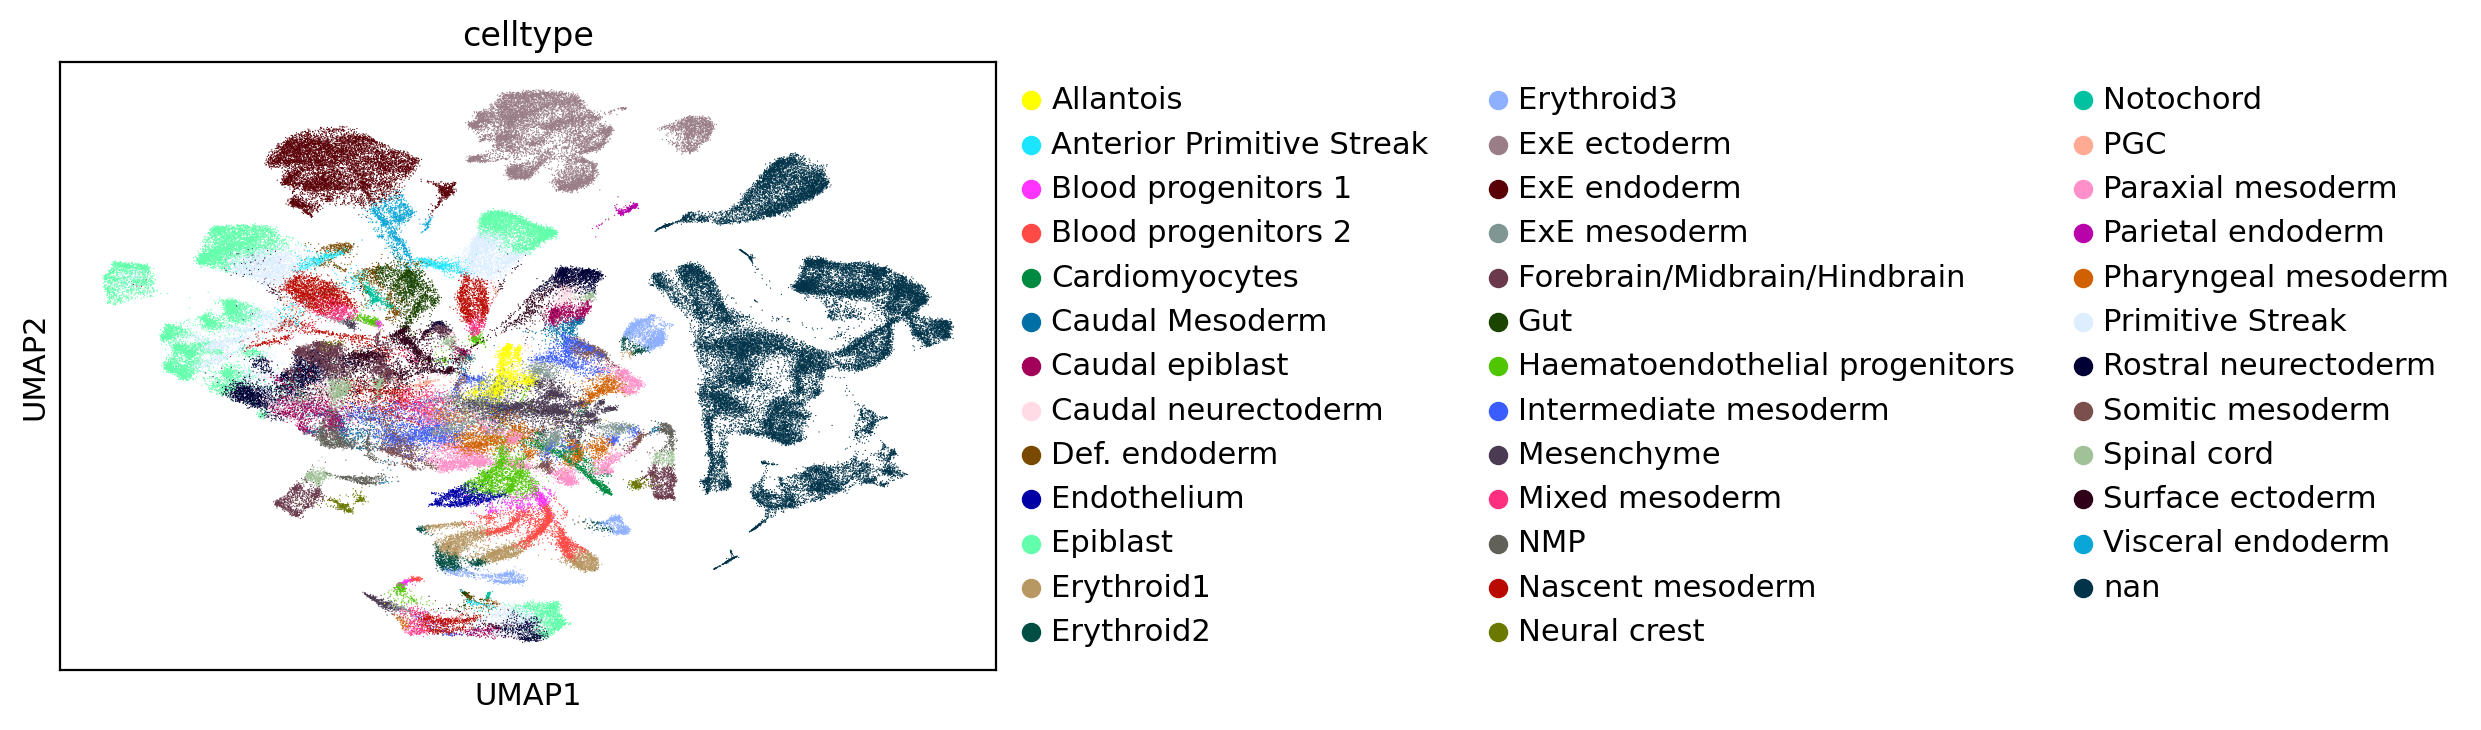

In [12]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/'
sc.pl.umap(adata, color='celltype', save='_celltype_before_correction.png')

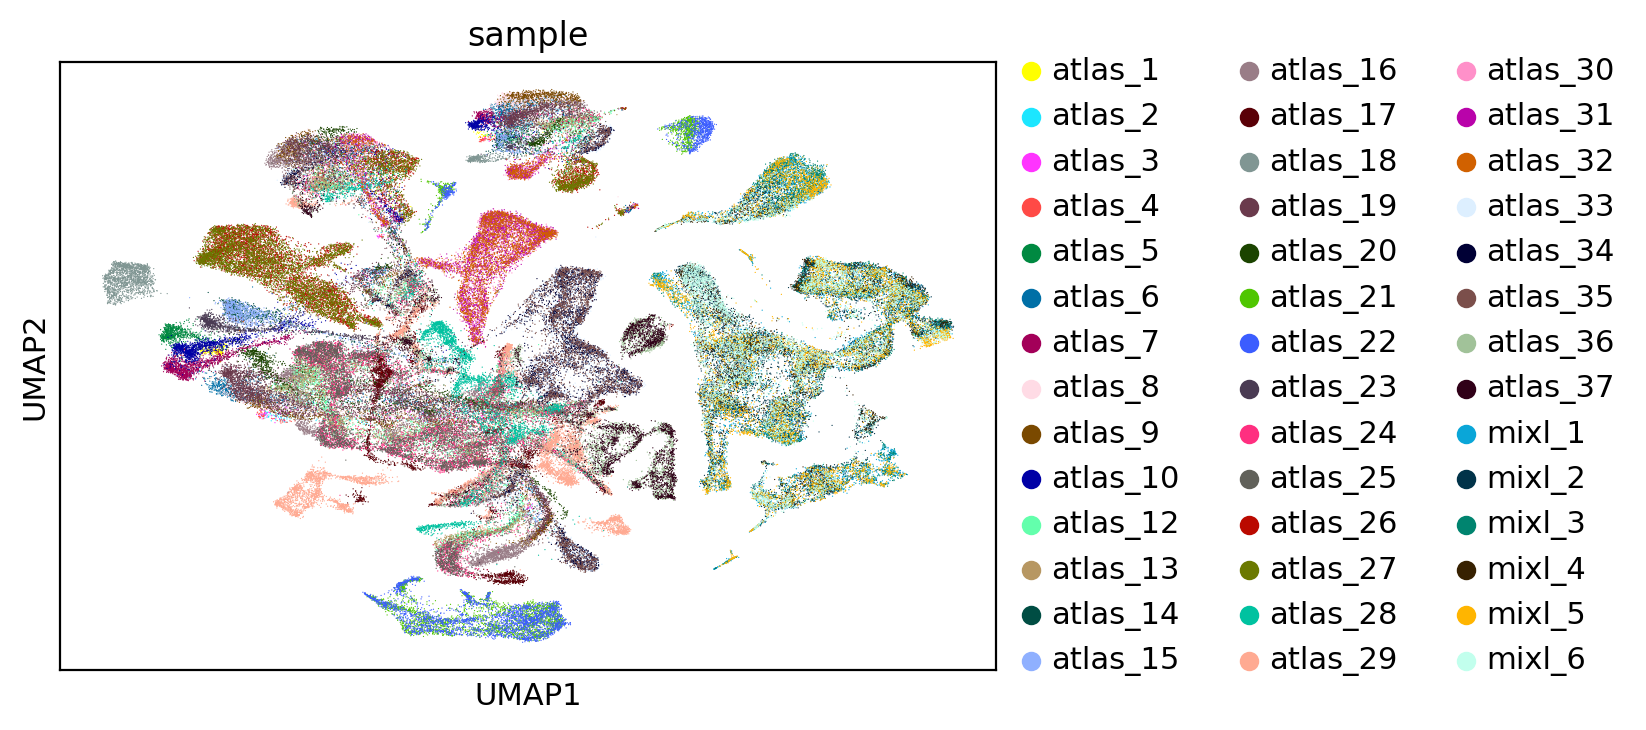

In [13]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/'
sc.pl.umap(adata, color='sample', save='_sample_before_correction.png')

In [14]:
Results = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/mixl_chim_atlas_analysis.h5"
adata = sc.read(Results)

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


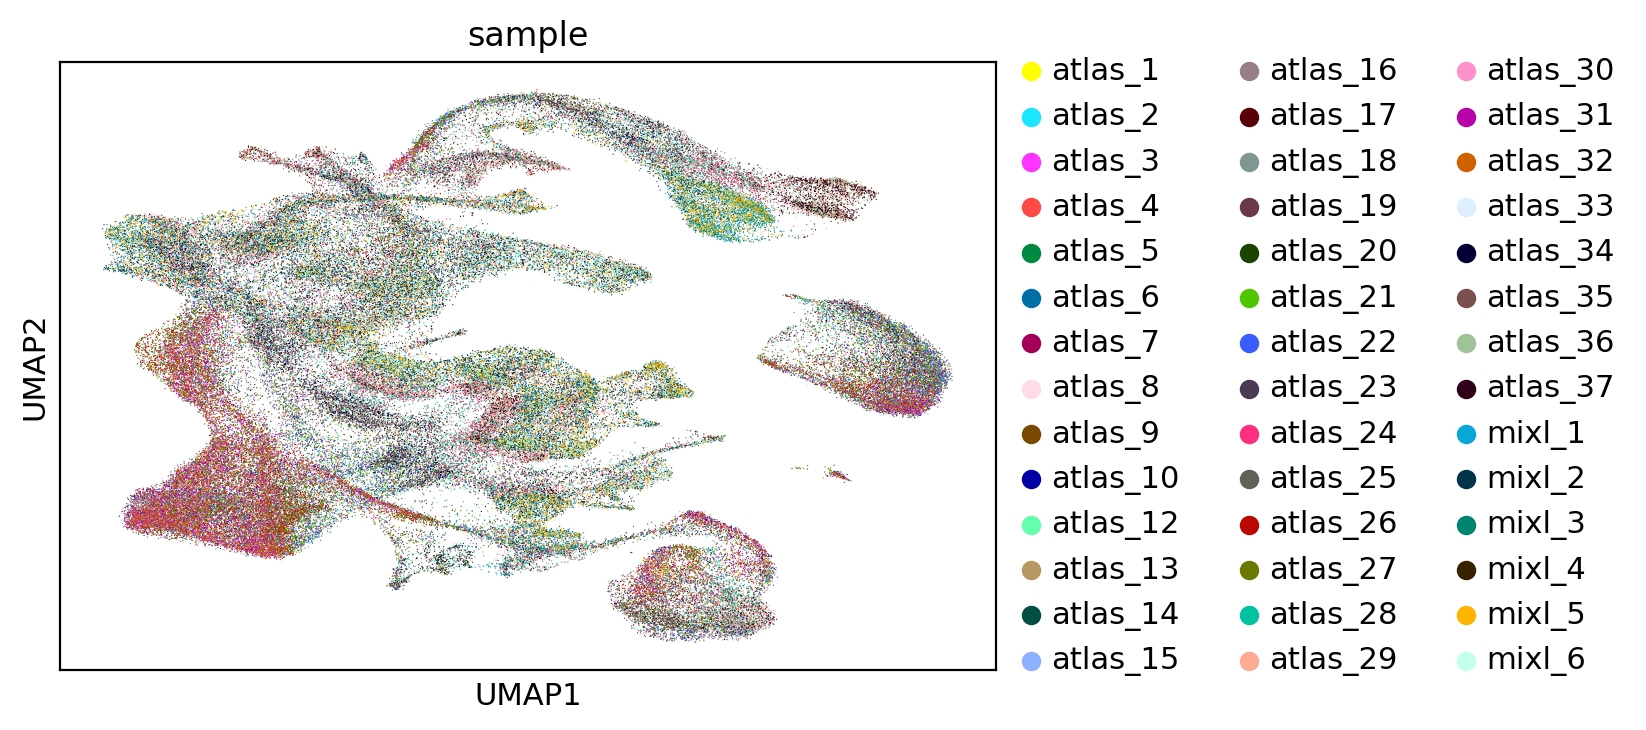

In [15]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/'
sc.pl.umap(adata, color='sample', save='_sample_after_correction.png')

In [16]:
# UMAP celltype with chimaera in grey
adata.obs['origin'] = np.where(adata.obs['tdTom'] != 'nan', 'chimaera', 'atlas')

adata.obs['celltype_atlas'] = np.where(adata.obs['origin'] == 'atlas', adata.obs['celltype'], 'chimaera')

In [24]:
adata.uns['celltype_atlas_colors'] = ['#532C8A', '#c19f70', '#f9decf', '#c9a997', '#B51D8D', '#9e6762', '#3F84AA', '#354E23', '#F397C0', '#ff891c', '#635547', '#C72228', '#f79083', '#EF4E22', '#989898', '#7F6874', '#8870ad', '#647a4f', '#EF5A9D', '#FBBE92', '#139992', '#cc7818', '#DFCDE4', '#C594BF', '#C3C388', '#8EC792', '#0F4A9C', '#8DB5CE', '#1A1A1A', '#FACB12', '#C9EBFB', '#DABE99', '#65A83E', '#005579', '#CDE088', '#f7f79e', '#F6BFCB', '#dbdbdb']

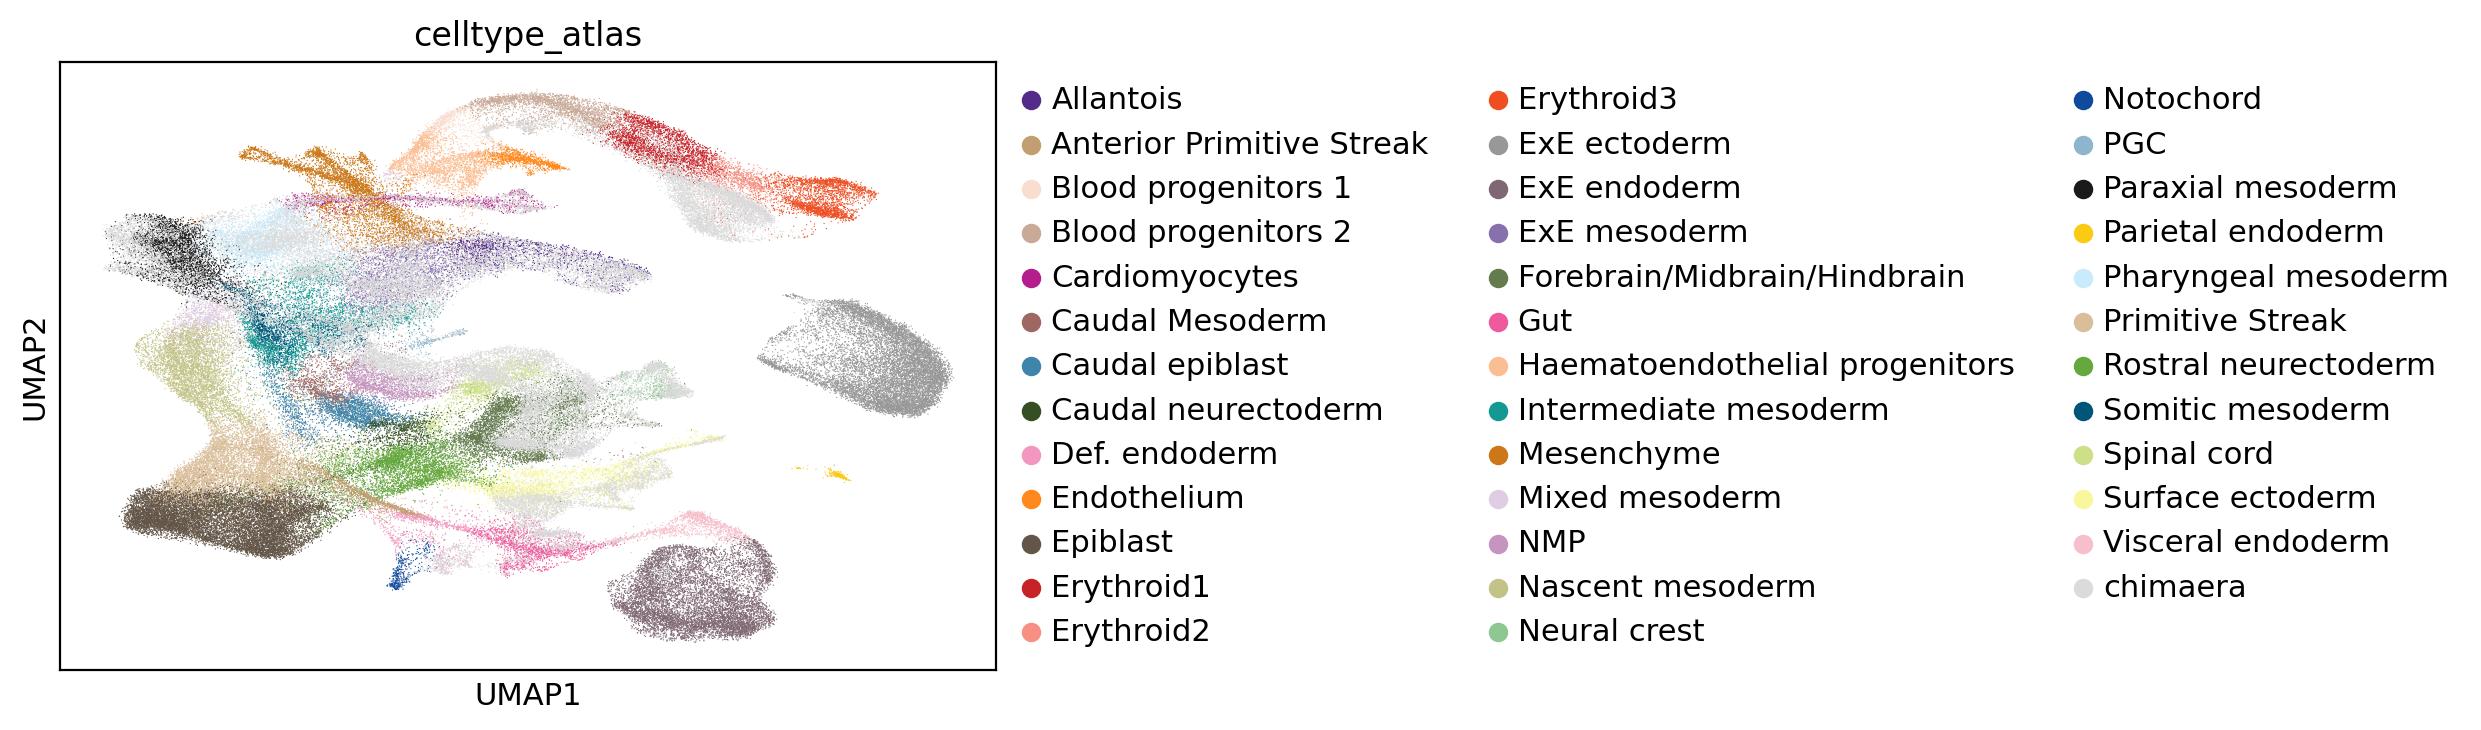

In [25]:
sc.settings.figdir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/'
sc.pl.umap(adata, color='celltype_atlas', save='_celltype_chimaera_grey.png')